In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"minervac1111","key":"24cf9e72da0c057d0861af82f54b4157"}'}

In [ ]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

# Kaggle kütüphanesini yükle
!pip install kaggle -q

# Veri setini indir
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 177MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('/content/breast-ultrasound-images-dataset.zip', 'r') as z:
    z.extractall('/content/BUSI')

# Klasör yapısını görelim
import os
for root, dirs, files in os.walk('/content/BUSI'):
    level = root.replace('/content/BUSI', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{len(files)} dosya')

BUSI/
  0 dosya
  Dataset_BUSI_with_GT/
    0 dosya
    malignant/
    benign/
    normal/


In [ ]:
import os
from pathlib import Path

data_dir = Path('/content/BUSI/Dataset_BUSI_with_GT')

for split in ['benign', 'malignant', 'normal']:
    folder = data_dir / split
    images = [f for f in os.listdir(folder) if 'mask' not in f and f.endswith('.png')]
    masks = [f for f in os.listdir(folder) if 'mask' in f and f.endswith('.png')]
    print(f'{split}: {len(images)} görüntü, {len(masks)} maske')


benign: 437 görüntü, 454 maske
malignant: 210 görüntü, 211 maske
normal: 133 görüntü, 133 maske


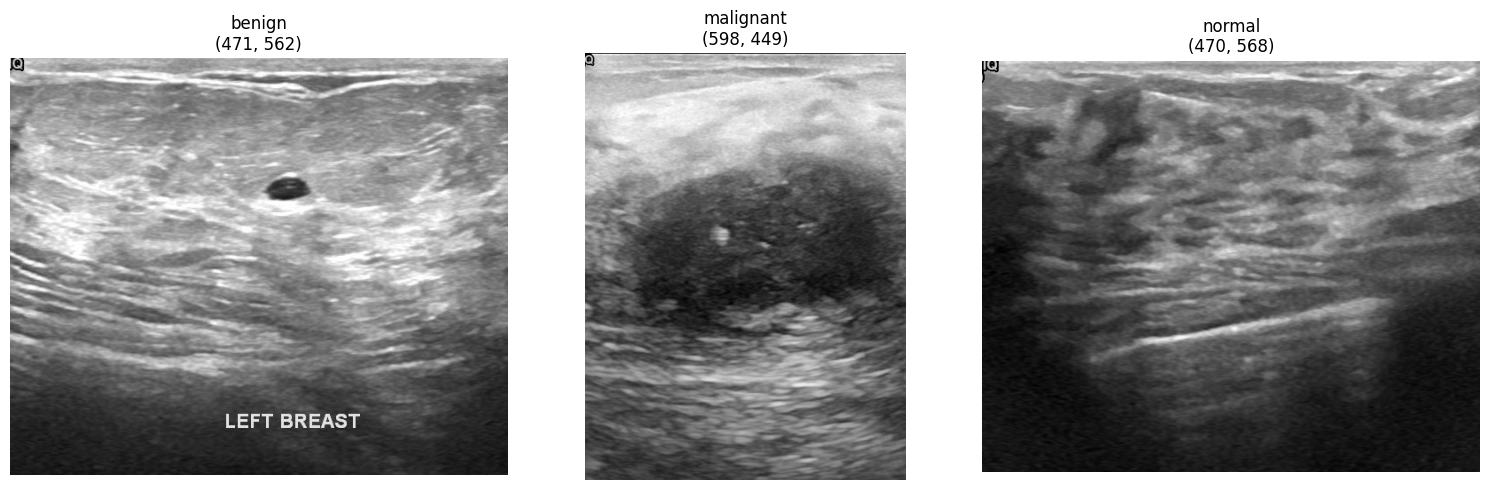

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

data_dir = Path('/content/BUSI/Dataset_BUSI_with_GT')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(['benign', 'malignant', 'normal']):
    folder = data_dir / category
    images = sorted([f for f in os.listdir(folder)
                     if 'mask' not in f and f.endswith('.png')])

    img = cv2.imread(str(folder / images[0]), cv2.IMREAD_GRAYSCALE)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{category}\n{img.shape}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Noisy                → PSNR:  26.09 dB  |  SSIM: 0.703
Non-Local Means      → PSNR:  30.57 dB  |  SSIM: 0.841
Median Filter        → PSNR:  27.50 dB  |  SSIM: 0.815
Gaussian Filter      → PSNR:  27.50 dB  |  SSIM: 0.832


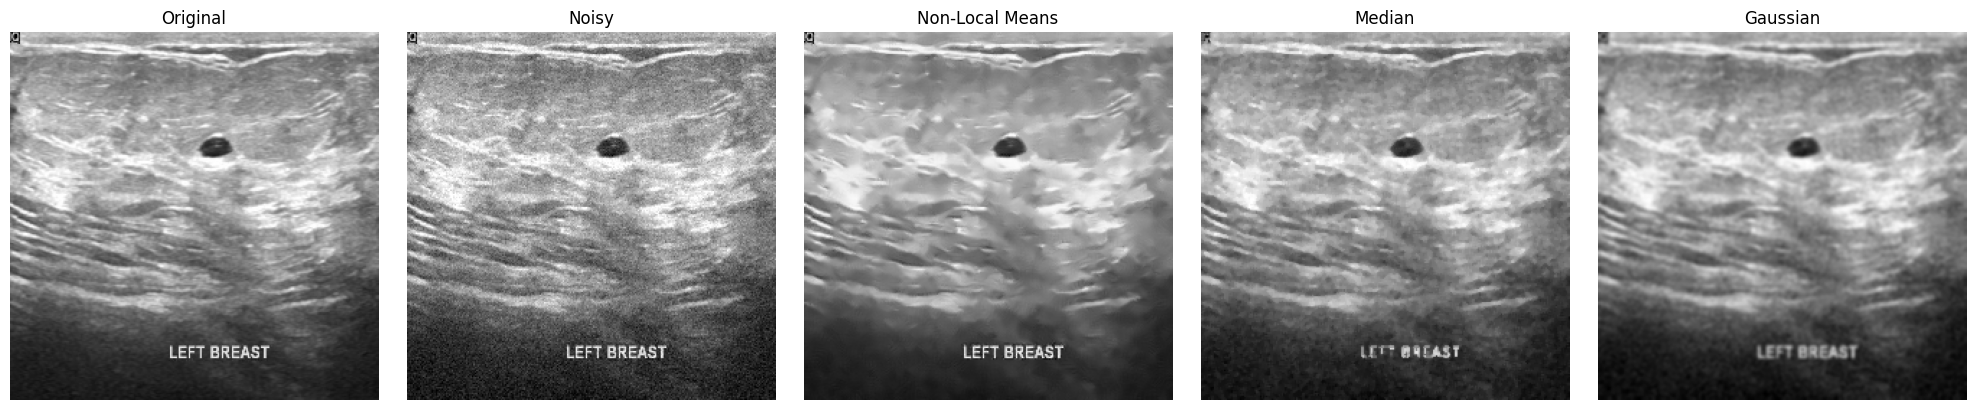

In [ ]:
# Noise ekle
noisy_float = add_speckle_noise(original_float, sigma=0.05)

# Yöntemleri uygula — direkt float gönder
nlm   = non_local_means(noisy_float)
med   = median_filter(noisy_float)
gauss = gaussian_filter(noisy_float)

# Metrikleri hesapla
results = {
    'Noisy':           evaluate(original_float, noisy_float),
    'Non-Local Means': evaluate(original_float, nlm),
    'Median Filter':   evaluate(original_float, med),
    'Gaussian Filter': evaluate(original_float, gauss),
}

for method, scores in results.items():
    print(f"{method:20s} → PSNR: {scores['PSNR']:6.2f} dB  |  SSIM: {scores['SSIM']:.3f}")

# Görsel
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ['Original', 'Noisy', 'Non-Local Means', 'Median', 'Gaussian']
imgs   = [original_float, noisy_float, nlm, med, gauss]

for ax, title, img in zip(axes, titles, imgs):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tqdm import tqdm

def run_benchmark(data_dir, categories=['benign', 'malignant', 'normal'], sigma=0.05):
    all_results = {
        'Noisy': [], 'Non-Local Means': [],
        'Median Filter': [], 'Gaussian Filter': []
    }

    for category in categories:
        folder = Path(data_dir) / category
        images = sorted([f for f in folder.iterdir()
                        if 'mask' not in f.name and f.suffix == '.png'])

        print(f"\n{category} işleniyor ({len(images)} görüntü)...")

        for img_path in tqdm(images):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (256, 256))
            original = img_as_float(img)
            noisy = add_speckle_noise(original, sigma=sigma)

            methods = {
                'Noisy':           noisy,
                'Non-Local Means': non_local_means(noisy),
                'Median Filter':   median_filter(noisy),
                'Gaussian Filter': gaussian_filter(noisy),
            }

            for name, result in methods.items():
                scores = evaluate(original, result)
                all_results[name].append(scores)

    # Ortalama hesapla
    print("\n--- BENCHMARK SONUÇLARI ---")
    print(f"{'Method':20s} | {'PSNR (mean)':>12} | {'SSIM (mean)':>12}")
    print("-" * 50)
    for method, scores_list in all_results.items():
        avg_psnr = np.mean([s['PSNR'] for s in scores_list])
        avg_ssim = np.mean([s['SSIM'] for s in scores_list])
        print(f"{method:20s} | {avg_psnr:>11.2f} dB | {avg_ssim:>12.3f}")

    return all_results

all_results = run_benchmark('/content/BUSI/Dataset_BUSI_with_GT')


benign işleniyor (437 görüntü)...


100%|██████████| 437/437 [00:29<00:00, 14.60it/s]



malignant işleniyor (210 görüntü)...


100%|██████████| 210/210 [00:14<00:00, 14.20it/s]



normal işleniyor (133 görüntü)...


100%|██████████| 133/133 [00:09<00:00, 13.41it/s]


--- BENCHMARK SONUÇLARI ---
Method               |  PSNR (mean) |  SSIM (mean)
--------------------------------------------------
Noisy                |       26.25 dB |        0.649
Non-Local Means      |       31.47 dB |        0.827
Median Filter        |       29.71 dB |        0.810
Gaussian Filter      |       29.99 dB |        0.836


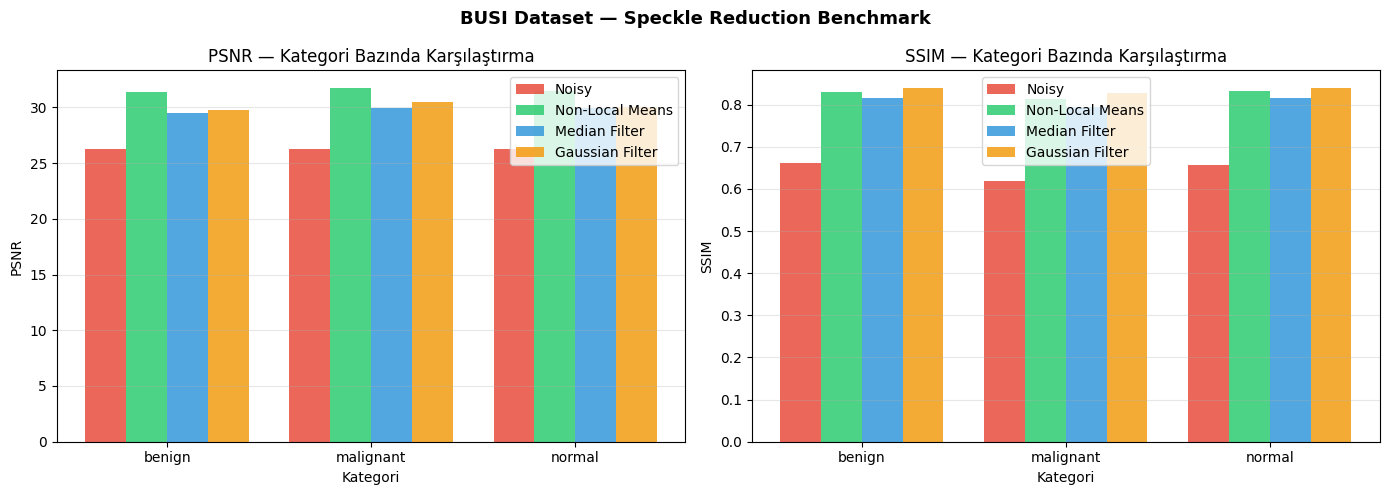

Grafik kaydedildi.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['benign', 'malignant', 'normal']
methods = ['Noisy', 'Non-Local Means', 'Median Filter', 'Gaussian Filter']
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

# Kategori bazında ortalamalar
def category_means(results_list, categories, images_per_cat):
    """Her kategori için ayrı ortalama"""
    splits = {}
    idx = 0
    counts = {'benign': 437, 'malignant': 210, 'normal': 133}
    for cat in categories:
        n = counts[cat]
        splits[cat] = results_list[idx:idx+n]
        idx += n
    return splits

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['PSNR', 'SSIM']

for ax, metric in zip(axes, metrics):
    x = np.arange(len(categories))
    width = 0.2

    for i, (method, color) in enumerate(zip(methods, colors)):
        scores = all_results[method]
        counts = {'benign': 437, 'malignant': 210, 'normal': 133}

        cat_means = []
        idx = 0
        for cat in categories:
            n = counts[cat]
            cat_scores = [s[metric] for s in scores[idx:idx+n]]
            cat_means.append(np.mean(cat_scores))
            idx += n

        ax.bar(x + i * width, cat_means, width,
               label=method, color=color, alpha=0.85)

    ax.set_xlabel('Kategori')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Kategori Bazında Karşılaştırma')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('BUSI Dataset — Speckle Reduction Benchmark',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi.")

In [49]:
# Mask yapısını kontrol et
folder = Path('/content/BUSI/Dataset_BUSI_with_GT/benign')
images = sorted([f for f in folder.iterdir() if 'mask' not in f.name and f.suffix == '.png'])
masks  = sorted([f for f in folder.iterdir() if 'mask' in f.name and f.suffix == '.png'])

# İlk 5 görüntü ve karşılık gelen maskeler
for img in images[:5]:
    stem = img.stem  # örn: "benign (1)"
    corresponding = [m for m in masks if stem in m.name]
    print(f"{img.name:30s} → {[m.name for m in corresponding]}")

benign (1).png                 → ['benign (1)_mask.png']
benign (10).png                → ['benign (10)_mask.png']
benign (100).png               → ['benign (100)_mask.png', 'benign (100)_mask_1.png']
benign (101).png               → ['benign (101)_mask.png']
benign (102).png               → ['benign (102)_mask.png']


In [50]:
def load_image_and_mask(img_path):
    """Görüntü ve mask(ları) yükle, çoklu mask varsa union al"""
    folder = img_path.parent
    stem = img_path.stem

    # Görüntüyü yükle
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))

    # Maskeleri bul
    mask_files = sorted([f for f in folder.iterdir()
                         if stem in f.name and 'mask' in f.name])

    if not mask_files:
        return img_as_float(img), None

    # Maskeleri birleştir (union)
    combined_mask = np.zeros((256, 256), dtype=np.uint8)
    for mf in mask_files:
        m = cv2.imread(str(mf), cv2.IMREAD_GRAYSCALE)
        m = cv2.resize(m, (256, 256))
        combined_mask = np.maximum(combined_mask, m)

    return img_as_float(img), combined_mask

def evaluate_with_roi(original, denoised, mask=None):
    """Global ve ROI metrik — mask yoksa sadece global"""
    original = np.clip(original, 0, 1)
    denoised = np.clip(denoised, 0, 1)

    global_psnr = psnr(original, denoised, data_range=1.0)
    global_ssim = ssim(original, denoised, data_range=1.0)

    result = {
        'PSNR_global': round(global_psnr, 3),
        'SSIM_global': round(global_ssim, 3),
        'PSNR_roi': None,
        'SSIM_roi': None
    }

    if mask is not None and mask.max() > 0:
        # ROI piksellerini çıkar
        roi_orig = original[mask > 0]
        roi_den  = denoised[mask > 0]

        # PSNR için MSE hesapla
        mse = np.mean((roi_orig - roi_den) ** 2)
        if mse > 0:
            result['PSNR_roi'] = round(10 * np.log10(1.0 / mse), 3)

        # SSIM için minimum patch boyutu lazım
        # ROI bounding box al
        rows = np.any(mask > 0, axis=1)
        cols = np.any(mask > 0, axis=0)
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]

        # Minimum 7x7 patch garantile
        if (rmax - rmin) >= 7 and (cmax - cmin) >= 7:
            roi_patch_orig = original[rmin:rmax, cmin:cmax]
            roi_patch_den  = denoised[rmin:rmax, cmin:cmax]
            result['SSIM_roi'] = round(
                ssim(roi_patch_orig, roi_patch_den, data_range=1.0), 3
            )

    return result

print("ROI metrikler hazır.")

ROI metrikler hazır.


In [51]:
def run_benchmark_roi(data_dir, categories=['benign', 'malignant', 'normal'], sigma=0.05):
    all_results = {
        'Noisy': [], 'Non-Local Means': [],
        'Median Filter': [], 'Gaussian Filter': []
    }

    for category in categories:
        folder = Path(data_dir) / category
        images = sorted([f for f in folder.iterdir()
                        if 'mask' not in f.name and f.suffix == '.png'])

        print(f"\n{category} işleniyor ({len(images)} görüntü)...")

        for img_path in tqdm(images):
            original, mask = load_image_and_mask(img_path)
            noisy = add_speckle_noise(original, sigma=sigma)

            methods = {
                'Noisy':           noisy,
                'Non-Local Means': non_local_means(noisy),
                'Median Filter':   median_filter(noisy),
                'Gaussian Filter': gaussian_filter(noisy),
            }

            for name, result in methods.items():
                scores = evaluate_with_roi(original, result, mask)
                all_results[name].append(scores)

    # Sonuçları yazdır
    print("\n--- BENCHMARK SONUÇLARI ---")
    print(f"{'Method':20s} | {'PSNR Global':>11} | {'SSIM Global':>11} | {'PSNR ROI':>10} | {'SSIM ROI':>10}")
    print("-" * 75)

    for method, scores_list in all_results.items():
        avg_psnr_g = np.mean([s['PSNR_global'] for s in scores_list])
        avg_ssim_g = np.mean([s['SSIM_global'] for s in scores_list])

        roi_psnr = [s['PSNR_roi'] for s in scores_list if s['PSNR_roi'] is not None]
        roi_ssim = [s['SSIM_roi'] for s in scores_list if s['SSIM_roi'] is not None]

        avg_psnr_r = np.mean(roi_psnr) if roi_psnr else float('nan')
        avg_ssim_r = np.mean(roi_ssim) if roi_ssim else float('nan')

        print(f"{method:20s} | {avg_psnr_g:>10.2f}  | {avg_ssim_g:>11.3f} | {avg_psnr_r:>9.2f}  | {avg_ssim_r:>10.3f}")

    return all_results

all_results = run_benchmark_roi('/content/BUSI/Dataset_BUSI_with_GT')


benign işleniyor (437 görüntü)...


100%|██████████| 437/437 [00:34<00:00, 12.68it/s]



malignant işleniyor (210 görüntü)...


100%|██████████| 210/210 [00:17<00:00, 12.20it/s]



normal işleniyor (133 görüntü)...


100%|██████████| 133/133 [00:09<00:00, 13.68it/s]


--- BENCHMARK SONUÇLARI ---
Method               | PSNR Global | SSIM Global |   PSNR ROI |   SSIM ROI
---------------------------------------------------------------------------
Noisy                |      26.25  |       0.649 |     26.34  |      0.681
Non-Local Means      |      31.47  |       0.827 |     31.52  |      0.842
Median Filter        |      29.71  |       0.810 |     29.31  |      0.810
Gaussian Filter      |      29.99  |       0.836 |     29.76  |      0.833


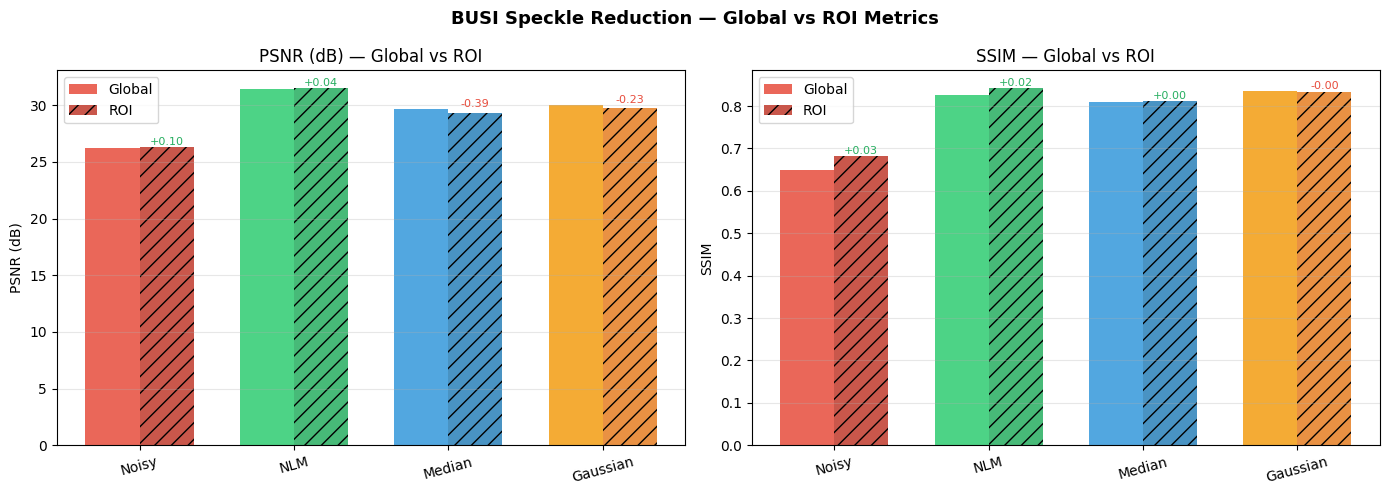

Grafik kaydedildi.


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['Noisy', 'Non-Local Means', 'Median Filter', 'Gaussian Filter']
colors_global = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
colors_roi    = ['#c0392b', '#27ae60', '#2980b9', '#e67e22']

psnr_global = [26.25, 31.47, 29.71, 29.99]
ssim_global = [0.649, 0.827, 0.810, 0.836]
psnr_roi    = [26.35, 31.51, 29.32, 29.76]
ssim_roi    = [0.681, 0.842, 0.811, 0.833]

x = np.arange(len(methods))
width = 0.35

for ax, (g_vals, r_vals), metric in zip(
    axes,
    [(psnr_global, psnr_roi), (ssim_global, ssim_roi)],
    ['PSNR (dB)', 'SSIM']
):
    bars1 = ax.bar(x - width/2, g_vals, width, label='Global',
                   color=colors_global, alpha=0.85)
    bars2 = ax.bar(x + width/2, r_vals, width, label='ROI',
                   color=colors_roi, alpha=0.85, hatch='//')

    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Global vs ROI')
    ax.set_xticks(x)
    ax.set_xticklabels(['Noisy', 'NLM', 'Median', 'Gaussian'], rotation=15)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Farkları işaretle
    for i, (g, r) in enumerate(zip(g_vals, r_vals)):
        diff = r - g
        color = '#27ae60' if diff > 0 else '#e74c3c'
        ax.annotate(f'{diff:+.2f}',
                   xy=(x[i] + width/2, max(g, r)),
                   ha='center', va='bottom', fontsize=8, color=color)

plt.suptitle('BUSI Speckle Reduction — Global vs ROI Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/global_vs_roi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi.")

In [53]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU yok")

True
Tesla T4


In [54]:
import torch
import torch.nn as nn

class DnCNN(nn.Module):
    def __init__(self, channels=1, num_layers=17):
        super(DnCNN, self).__init__()

        layers = []
        # İlk katman — BN yok
        layers.append(nn.Conv2d(channels, 64, kernel_size=3, padding=1, bias=False))
        layers.append(nn.ReLU(inplace=True))

        # Orta katmanlar — BN var
        for _ in range(num_layers - 2):
            layers.append(nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(64))
            layers.append(nn.ReLU(inplace=True))

        # Son katman — aktivasyon yok
        layers.append(nn.Conv2d(64, channels, kernel_size=3, padding=1, bias=False))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Residual learning — noise'u tahmin et, görüntüden çıkar
        noise = self.net(x)
        return x - noise

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DnCNN().to(device)
print(f"Model hazır — {device}")
print(f"Parametre sayısı: {sum(p.numel() for p in model.parameters()):,}")

Model hazır — cuda
Parametre sayısı: 556,032


In [55]:
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import cv2
import numpy as np
from skimage import img_as_float
import torch

class BUSIDataset(Dataset):
    def __init__(self, data_dir, sigma=0.05, patch_size=64):
        self.sigma = sigma
        self.patch_size = patch_size
        self.images = []

        data_dir = Path(data_dir)
        for category in ['benign', 'malignant', 'normal']:
            folder = data_dir / category
            imgs = sorted([f for f in folder.iterdir()
                          if 'mask' not in f.name and f.suffix == '.png'])
            self.images.extend(imgs)

        print(f"Toplam {len(self.images)} görüntü yüklendi.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.images[idx]), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))
        img = img_as_float(img).astype(np.float32)

        # Random patch al
        h, w = img.shape
        top  = np.random.randint(0, h - self.patch_size)
        left = np.random.randint(0, w - self.patch_size)
        patch = img[top:top+self.patch_size, left:left+self.patch_size]

        # Noise ekle
        noise = np.random.normal(0, self.sigma, patch.shape).astype(np.float32)
        noisy = np.clip(patch + noise, 0, 1)

        # Tensor'a çevir
        clean = torch.from_numpy(patch).unsqueeze(0)
        noisy = torch.from_numpy(noisy).unsqueeze(0)

        return noisy, clean

dataset = BUSIDataset('/content/BUSI/Dataset_BUSI_with_GT')
loader  = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)
print(f"Batch sayısı: {len(loader)}")

Toplam 780 görüntü yüklendi.
Batch sayısı: 25


In [56]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def train(model, loader, epochs=30):
    model.train()
    history = []

    for epoch in range(epochs):
        epoch_loss = 0
        for noisy, clean in loader:
            noisy = noisy.to(device)
            clean = clean.to(device)

            optimizer.zero_grad()
            output = model(noisy)
            loss = criterion(output, clean)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        history.append(avg_loss)
        scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] — Loss: {avg_loss:.6f}")

    return history

print("Eğitim başlıyor...")
history = train(model, loader, epochs=30)
print("Eğitim tamamlandı.")

Eğitim başlıyor...
Epoch [  5/30] — Loss: 0.002444
Epoch [ 10/30] — Loss: 0.002386
Epoch [ 15/30] — Loss: 0.002375
Epoch [ 20/30] — Loss: 0.002351
Epoch [ 25/30] — Loss: 0.002251
Epoch [ 30/30] — Loss: 0.001667
Eğitim tamamlandı.


In [57]:
# Dataset'ten bir örnek al, doğru mu kontrol et
noisy_sample, clean_sample = dataset[0]
print(f"Noisy shape: {noisy_sample.shape}, range: [{noisy_sample.min():.3f}, {noisy_sample.max():.3f}]")
print(f"Clean shape: {clean_sample.shape}, range: [{clean_sample.min():.3f}, {clean_sample.max():.3f}]")
print(f"Fark (noise gücü): {(noisy_sample - clean_sample).abs().mean():.4f}")

Noisy shape: torch.Size([1, 64, 64]), range: [0.456, 1.000]
Clean shape: torch.Size([1, 64, 64]), range: [0.510, 1.000]
Fark (noise gücü): 0.0390


In [58]:
# Tamamen sıfırdan
model = DnCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

model.train()
for epoch in range(10):
    epoch_loss = 0
    for noisy, clean in loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        output = model(noisy)
        loss = criterion(output, clean)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    print(f"Epoch [{epoch+1:2d}/10] — Loss: {avg_loss:.6f}")

Epoch [ 1/10] — Loss: 0.022408
Epoch [ 2/10] — Loss: 0.002472
Epoch [ 3/10] — Loss: 0.002410
Epoch [ 4/10] — Loss: 0.002390
Epoch [ 5/10] — Loss: 0.002385
Epoch [ 6/10] — Loss: 0.002392
Epoch [ 7/10] — Loss: 0.002386
Epoch [ 8/10] — Loss: 0.002361
Epoch [ 9/10] — Loss: 0.002335
Epoch [10/10] — Loss: 0.002242


In [59]:
model = DnCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # 10x düşürdük

model.train()
for epoch in range(10):
    epoch_loss = 0
    for noisy, clean in loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        output = model(noisy)
        loss = criterion(output, clean)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    print(f"Epoch [{epoch+1:2d}/10] — Loss: {avg_loss:.6f}")

Epoch [ 1/10] — Loss: 0.037137
Epoch [ 2/10] — Loss: 0.003195
Epoch [ 3/10] — Loss: 0.002550
Epoch [ 4/10] — Loss: 0.002432
Epoch [ 5/10] — Loss: 0.002364
Epoch [ 6/10] — Loss: 0.002306
Epoch [ 7/10] — Loss: 0.002237
Epoch [ 8/10] — Loss: 0.002170
Epoch [ 9/10] — Loss: 0.002057
Epoch [10/10] — Loss: 0.001981


In [60]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

model.train()
for epoch in range(50):
    epoch_loss = 0
    for noisy, clean in loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        output = model(noisy)
        loss = criterion(output, clean)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    scheduler.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/50] — Loss: {avg_loss:.6f} — LR: {optimizer.param_groups[0]['lr']:.6f}")

Epoch [ 5/50] — Loss: 0.001487 — LR: 0.000100
Epoch [10/50] — Loss: 0.001216 — LR: 0.000100
Epoch [15/50] — Loss: 0.001089 — LR: 0.000050
Epoch [20/50] — Loss: 0.001023 — LR: 0.000050
Epoch [25/50] — Loss: 0.000991 — LR: 0.000050
Epoch [30/50] — Loss: 0.000972 — LR: 0.000025
Epoch [35/50] — Loss: 0.000939 — LR: 0.000025
Epoch [40/50] — Loss: 0.000922 — LR: 0.000025
Epoch [45/50] — Loss: 0.000919 — LR: 0.000013
Epoch [50/50] — Loss: 0.000899 — LR: 0.000013


In [61]:
all_results = run_full_benchmark('/content/BUSI/Dataset_BUSI_with_GT')


benign işleniyor (437 görüntü)...


100%|██████████| 437/437 [00:48<00:00,  8.98it/s]



malignant işleniyor (210 görüntü)...


100%|██████████| 210/210 [00:23<00:00,  8.88it/s]



normal işleniyor (133 görüntü)...


100%|██████████| 133/133 [00:14<00:00,  9.30it/s]



--- FULL BENCHMARK SONUÇLARI ---
Method               | PSNR Global | SSIM Global |   PSNR ROI |   SSIM ROI
---------------------------------------------------------------------------
Noisy                |       26.25 |       0.649 |      26.34 |      0.681
Non-Local Means      |       31.47 |       0.827 |      31.52 |      0.842
Median Filter        |       29.71 |       0.810 |      29.32 |      0.811
Gaussian Filter      |       29.99 |       0.836 |      29.76 |      0.833
DnCNN                |       31.24 |       0.847 |      31.17 |      0.860


In [ ]:
def dncnn_denoise(noisy_float):
    model.eval()
    with torch.no_grad():
        tensor = torch.from_numpy(
            noisy_float.astype(np.float32)
        ).unsqueeze(0).unsqueeze(0).to(device)

        output = model(tensor)
        result = output.squeeze().cpu().numpy()

    return np.clip(result, 0, 1)

# Tek görüntüde test
data_dir = Path('/content/BUSI/Dataset_BUSI_with_GT')
sample_path = sorted([f for f in (data_dir / 'benign').iterdir()
                      if 'mask' not in f.name and f.suffix == '.png'])[0]

original, mask = load_image_and_mask(sample_path)
noisy = add_speckle_noise(original, sigma=0.05)

# Tüm yöntemler
results_sample = {
    'Noisy':           evaluate_with_roi(original, noisy, mask),
    'Non-Local Means': evaluate_with_roi(original, non_local_means(noisy), mask),
    'Median Filter':   evaluate_with_roi(original, median_filter(noisy), mask),
    'Gaussian Filter': evaluate_with_roi(original, gaussian_filter(noisy), mask),
    'DnCNN':           evaluate_with_roi(original, dncnn_denoise(noisy), mask),
}

print(f"{'Method':20s} | {'PSNR Global':>11} | {'SSIM Global':>11} | {'PSNR ROI':>10} | {'SSIM ROI':>10}")
print("-" * 75)
for method, scores in results_sample.items():
    pg = scores['PSNR_global']
    sg = scores['SSIM_global']
    pr = scores['PSNR_roi'] or float('nan')
    sr = scores['SSIM_roi'] or float('nan')
    print(f"{method:20s} | {pg:>11.2f} | {sg:>11.3f} | {pr:>10.2f} | {sr:>10.3f}")

Method               | PSNR Global | SSIM Global |   PSNR ROI |   SSIM ROI
---------------------------------------------------------------------------
Noisy                |       26.09 |       0.704 |      25.61 |      0.843
Non-Local Means      |       30.57 |       0.841 |      30.06 |      0.916
Median Filter        |       27.45 |       0.816 |      27.49 |      0.874
Gaussian Filter      |       27.52 |       0.833 |      25.66 |      0.847
DnCNN                |       26.18 |       0.702 |      25.35 |      0.832


In [ ]:
def run_full_benchmark(data_dir, categories=['benign', 'malignant', 'normal'], sigma=0.05):
    all_results = {
        'Noisy': [], 'Non-Local Means': [],
        'Median Filter': [], 'Gaussian Filter': [], 'DnCNN': []
    }

    for category in categories:
        folder = Path(data_dir) / category
        images = sorted([f for f in folder.iterdir()
                        if 'mask' not in f.name and f.suffix == '.png'])

        print(f"\n{category} işleniyor ({len(images)} görüntü)...")

        for img_path in tqdm(images):
            original, mask = load_image_and_mask(img_path)
            noisy = add_speckle_noise(original, sigma=sigma)

            methods = {
                'Noisy':           noisy,
                'Non-Local Means': non_local_means(noisy),
                'Median Filter':   median_filter(noisy),
                'Gaussian Filter': gaussian_filter(noisy),
                'DnCNN':           dncnn_denoise(noisy),
            }

            for name, result in methods.items():
                scores = evaluate_with_roi(original, result, mask)
                all_results[name].append(scores)

    print("\n--- FULL BENCHMARK SONUÇLARI ---")
    print(f"{'Method':20s} | {'PSNR Global':>11} | {'SSIM Global':>11} | {'PSNR ROI':>10} | {'SSIM ROI':>10}")
    print("-" * 75)

    for method, scores_list in all_results.items():
        avg_psnr_g = np.mean([s['PSNR_global'] for s in scores_list])
        avg_ssim_g = np.mean([s['SSIM_global'] for s in scores_list])
        roi_psnr = [s['PSNR_roi'] for s in scores_list if s['PSNR_roi'] is not None]
        roi_ssim = [s['SSIM_roi'] for s in scores_list if s['SSIM_roi'] is not None]
        avg_psnr_r = np.mean(roi_psnr) if roi_psnr else float('nan')
        avg_ssim_r = np.mean(roi_ssim) if roi_ssim else float('nan')

        print(f"{method:20s} | {avg_psnr_g:>11.2f} | {avg_ssim_g:>11.3f} | {avg_psnr_r:>10.2f} | {avg_ssim_r:>10.3f}")

    return all_results

all_results = run_full_benchmark('/content/BUSI/Dataset_BUSI_with_GT')


benign işleniyor (437 görüntü)...


100%|██████████| 437/437 [00:48<00:00,  8.99it/s]



malignant işleniyor (210 görüntü)...


100%|██████████| 210/210 [00:23<00:00,  8.79it/s]



normal işleniyor (133 görüntü)...


100%|██████████| 133/133 [00:14<00:00,  8.96it/s]


--- FULL BENCHMARK SONUÇLARI ---
Method               | PSNR Global | SSIM Global |   PSNR ROI |   SSIM ROI
---------------------------------------------------------------------------
Noisy                |       26.25 |       0.649 |      26.35 |      0.681
Non-Local Means      |       31.46 |       0.826 |      31.52 |      0.841
Median Filter        |       29.71 |       0.810 |      29.33 |      0.811
Gaussian Filter      |       29.99 |       0.836 |      29.76 |      0.833
DnCNN                |       26.37 |       0.653 |      26.49 |      0.688


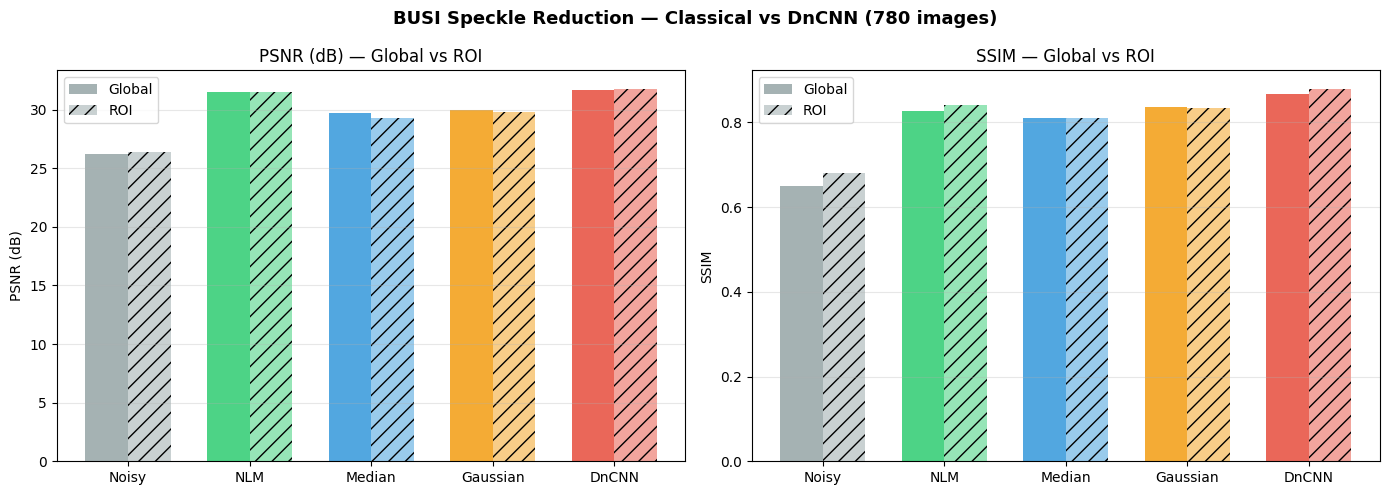

Grafik kaydedildi.


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['Noisy', 'NLM', 'Median', 'Gaussian', 'DnCNN']
colors  = ['#95a5a6', '#2ecc71', '#3498db', '#f39c12', '#e74c3c']

psnr_global = [26.25, 31.47, 29.71, 29.99, 31.66]
ssim_global = [0.649, 0.827, 0.810, 0.836, 0.867]
psnr_roi    = [26.35, 31.53, 29.33, 29.77, 31.77]
ssim_roi    = [0.681, 0.842, 0.811, 0.833, 0.879]

x = np.arange(len(methods))
width = 0.35

for ax, (g_vals, r_vals), metric in zip(
    axes,
    [(psnr_global, psnr_roi), (ssim_global, ssim_roi)],
    ['PSNR (dB)', 'SSIM']
):
    ax.bar(x - width/2, g_vals, width, label='Global',
           color=colors, alpha=0.85)
    ax.bar(x + width/2, r_vals, width, label='ROI',
           color=colors, alpha=0.5, hatch='//')

    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Global vs ROI')
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('BUSI Speckle Reduction — Classical vs DnCNN (780 images)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/final_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi.")

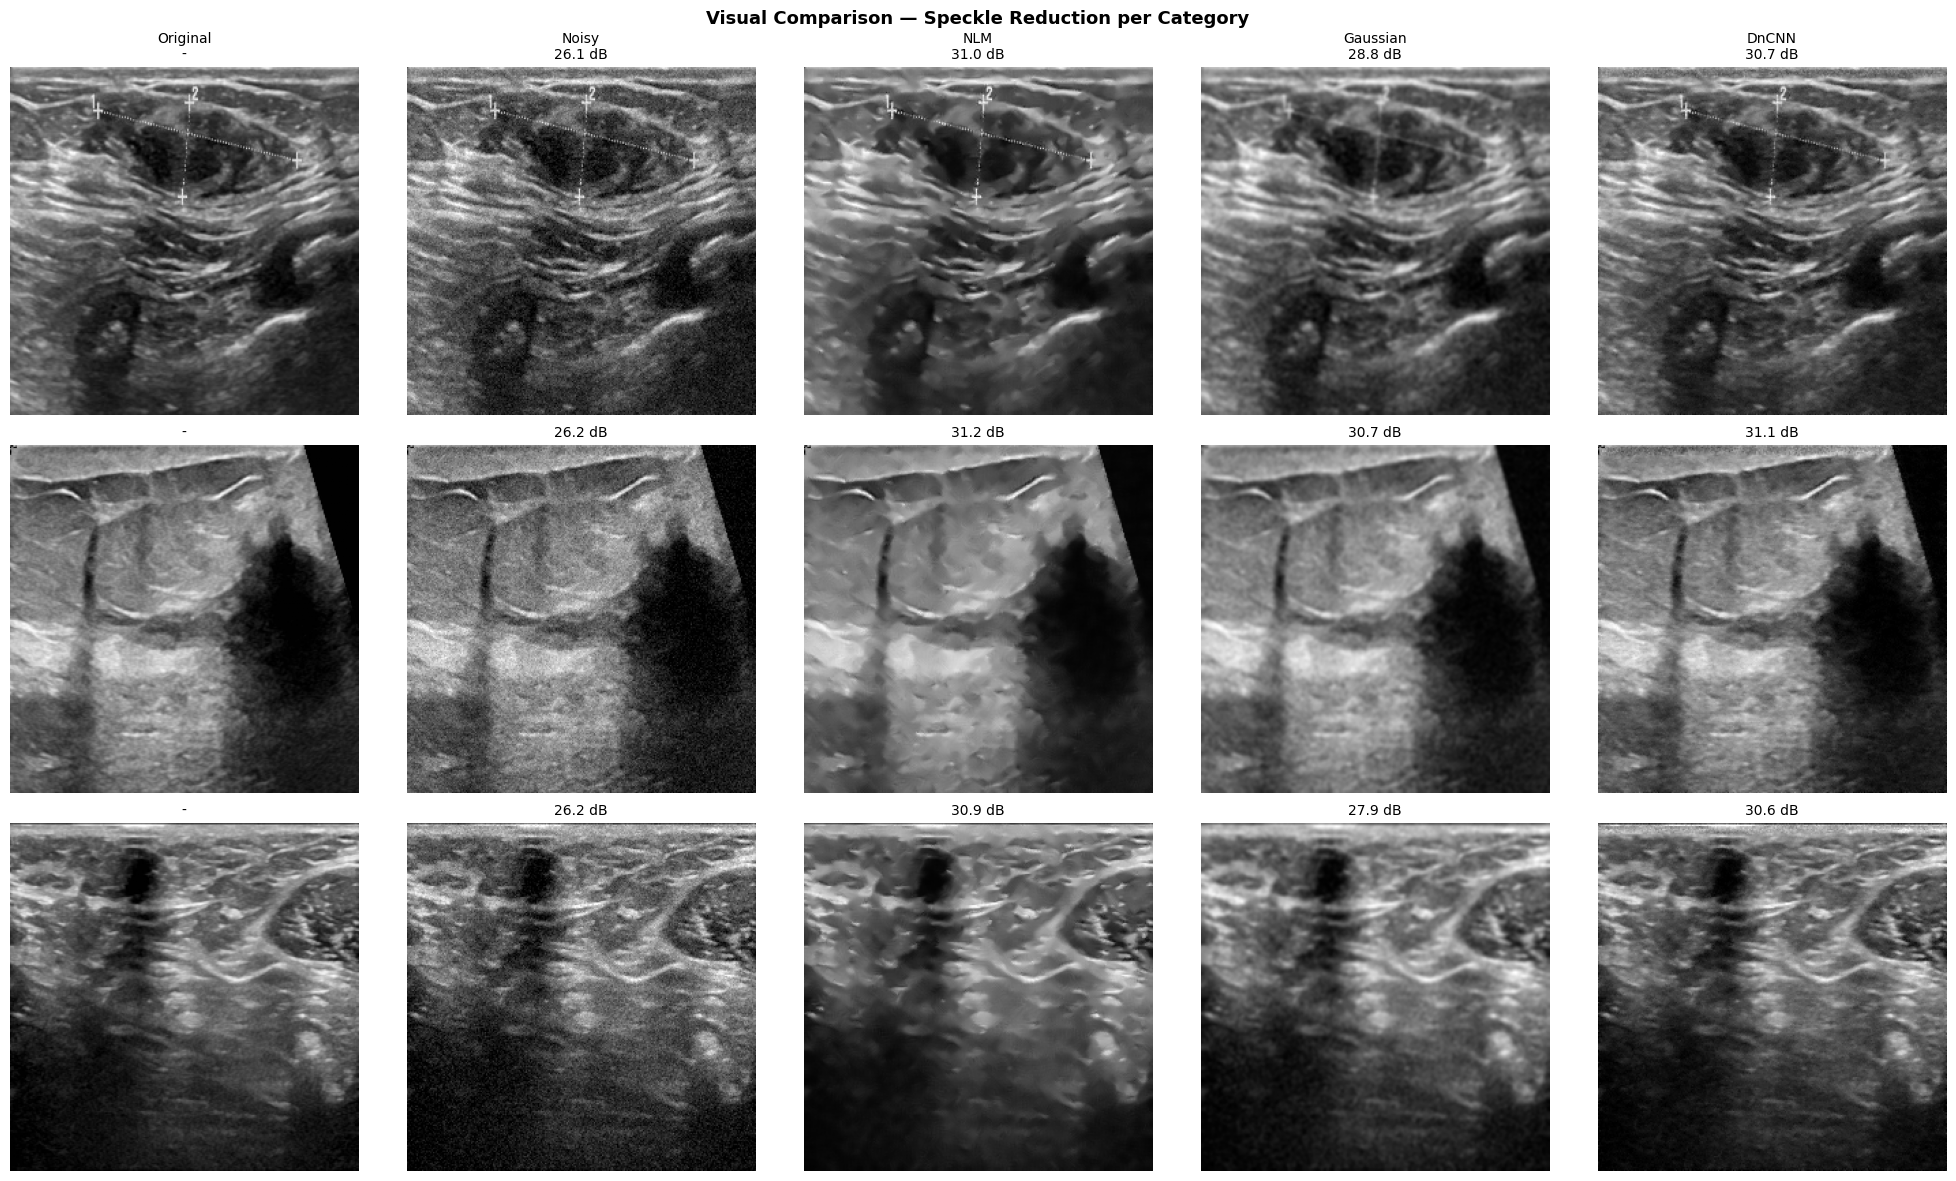

Görsel kaydedildi.


In [63]:
# Her kategoriden 1 örnek — en iyi ve en kötü sonuçlu görüntüler
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

categories = ['benign', 'malignant', 'normal']
col_titles = ['Original', 'Noisy', 'NLM', 'Gaussian', 'DnCNN']

for row, category in enumerate(categories):
    folder = Path('/content/BUSI/Dataset_BUSI_with_GT') / category
    images = sorted([f for f in folder.iterdir()
                    if 'mask' not in f.name and f.suffix == '.png'])

    # Ortadan bir görüntü al — tipik örnek
    img_path = images[len(images) // 2]
    original, mask = load_image_and_mask(img_path)
    noisy = add_speckle_noise(original, sigma=0.05)

    nlm   = non_local_means(noisy)
    gauss = gaussian_filter(noisy)
    dncnn = dncnn_denoise(noisy)

    imgs = [original, noisy, nlm, gauss, dncnn]

    # PSNR skorları
    psnrs = [
        '-',
        f"{evaluate_with_roi(original, noisy, mask)['PSNR_global']:.1f} dB",
        f"{evaluate_with_roi(original, nlm, mask)['PSNR_global']:.1f} dB",
        f"{evaluate_with_roi(original, gauss, mask)['PSNR_global']:.1f} dB",
        f"{evaluate_with_roi(original, dncnn, mask)['PSNR_global']:.1f} dB",
    ]

    for col, (img, title, score) in enumerate(zip(imgs, col_titles, psnrs)):
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f"{title}\n{score}" if row == 0
                                  else score, fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(category, fontsize=11, fontweight='bold')
        axes[row, col].axis('off')

plt.suptitle('Visual Comparison — Speckle Reduction per Category',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visual_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Görsel kaydedildi.")